In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, optimizers, utils
from tensorflow.keras.applications.efficientnet import EfficientNetB1, preprocess_input

In [2]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow version:", tf.__version__)

Num GPUs Available: 0
TensorFlow version: 2.19.0


In [5]:
DATA_DIR = r"C:\Users\User\Downloads\Wound_dataset copy"
IMG_SIZE = (224, 224)
BATCH_SIZE = 64
SEED = 42

In [6]:
train_data = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

val_test_data = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb"
)

# Split validation subset into validation and test (50/50)
val_test_batches = tf.data.experimental.cardinality(val_test_data)
val_size = val_test_batches // 2
test_size = val_test_batches - val_size

validation_data = val_test_data.take(val_size)
testing_data = val_test_data.skip(val_size)

class_names = train_data.class_names
NUM_CLASSES = len(class_names)
print("Class names:", class_names)
print(f"Training batches: {tf.data.experimental.cardinality(train_data)}")
print(f"Validation batches: {tf.data.experimental.cardinality(validation_data)}")
print(f"Testing batches: {tf.data.experimental.cardinality(testing_data)}")


Found 2940 files belonging to 10 classes.
Using 2352 files for training.
Found 2940 files belonging to 10 classes.
Using 588 files for validation.
Class names: ['Abrasions', 'Bruises', 'Burns', 'Cut', 'Diabetic Wounds', 'Laseration', 'Normal', 'Pressure Wounds', 'Surgical Wounds', 'Venous Wounds']
Training batches: 37
Validation batches: 5
Testing batches: 5


In [7]:
def preprocess_for_model(img):
    img = tf.cast(img, tf.float32)
    return preprocess_input(img)

def preprocess_for_display(img):
    img = tf.cast(img, tf.float32) / 255.0
    return img

train_dataset = train_data.map(lambda x, y: (preprocess_for_model(x), y))
val_dataset   = validation_data.map(lambda x, y: (preprocess_for_model(x), y))
test_dataset  = testing_data.map(lambda x, y: (preprocess_for_model(x), y))
display_dataset = train_data.map(lambda x, y: (preprocess_for_display(x), y))

print("Preprocessing complete.")
print("You now have: train_dataset, val_dataset, and test_dataset ready for the model.")


Preprocessing complete.
You now have: train_dataset, val_dataset, and test_dataset ready for the model.


In [8]:
def dataset_to_numpy(dataset):
    x_data, y_data = [], []
    print("Converting dataset to NumPy...")
    for images, labels in dataset:
        x_data.append(images.numpy())
        y_data.append(labels.numpy())
    print("Concatenating all batches...")
    x_data_np = np.concatenate(x_data, axis=0)
    y_data_np = np.concatenate(y_data, axis=0)
    return x_data_np, y_data_np

print("--- Starting conversion to NumPy ---")
print("\n[1/3] Converting training data...")
x_train, y_train = dataset_to_numpy(train_dataset)
print(f"-> Done. x_train: {x_train.shape}, y_train: {y_train.shape}")

print("\n[2/3] Converting validation data...")
x_val, y_val = dataset_to_numpy(val_dataset)
print(f"-> Done. x_val: {x_val.shape}, y_val: {y_val.shape}")

print("\n[3/3] Converting testing data...")
x_test, y_test = dataset_to_numpy(test_dataset)
print(f"-> Done. x_test: {x_test.shape}, y_test: {y_test.shape}")
print("\n--- Conversion complete ---")

# One-hot labels (if you prefer model.fit on NumPy instead of tf.data)
print("\nFor Training Data:")
print("y_train shape before squeeze:", y_train.shape)
y_train_cat = utils.to_categorical(np.squeeze(y_train), NUM_CLASSES)
print("y_train one-hot shape:", y_train_cat.shape)

print("\nFor Validation Data:")
print("y_val shape before squeeze:", y_val.shape)
y_val_cat = utils.to_categorical(np.squeeze(y_val), NUM_CLASSES)
print("y_val one-hot shape:", y_val_cat.shape)

print("\nFor Testing Data:")
print("y_test shape before squeeze:", y_test.shape)
y_test_cat = utils.to_categorical(np.squeeze(y_test), NUM_CLASSES)
print("y_test one-hot shape:", y_test_cat.shape)
print("\n--- Label processing complete ---")


--- Starting conversion to NumPy ---

[1/3] Converting training data...
Converting dataset to NumPy...
Concatenating all batches...
-> Done. x_train: (2352, 224, 224, 3), y_train: (2352,)

[2/3] Converting validation data...
Converting dataset to NumPy...
Concatenating all batches...
-> Done. x_val: (320, 224, 224, 3), y_val: (320,)

[3/3] Converting testing data...
Converting dataset to NumPy...
Concatenating all batches...
-> Done. x_test: (268, 224, 224, 3), y_test: (268,)

--- Conversion complete ---

For Training Data:
y_train shape before squeeze: (2352,)
y_train one-hot shape: (2352, 10)

For Validation Data:
y_val shape before squeeze: (320,)
y_val one-hot shape: (320, 10)

For Testing Data:
y_test shape before squeeze: (268,)
y_test one-hot shape: (268, 10)

--- Label processing complete ---



--- Sample images from Training Set ---
Converting dataset to NumPy...
Concatenating all batches...


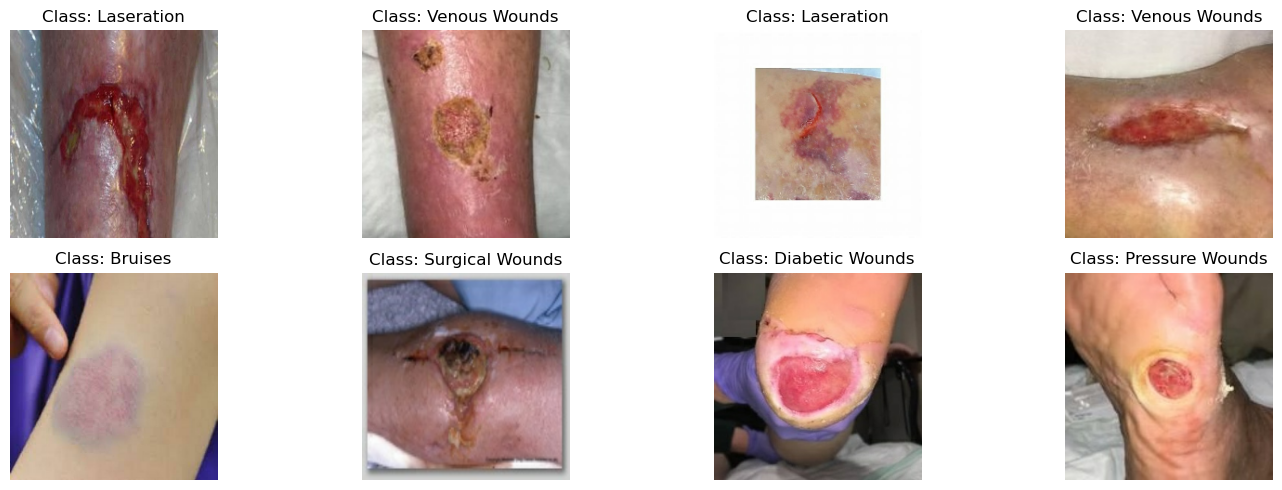


--- Sample images from Validation Set ---
Converting dataset to NumPy...
Concatenating all batches...


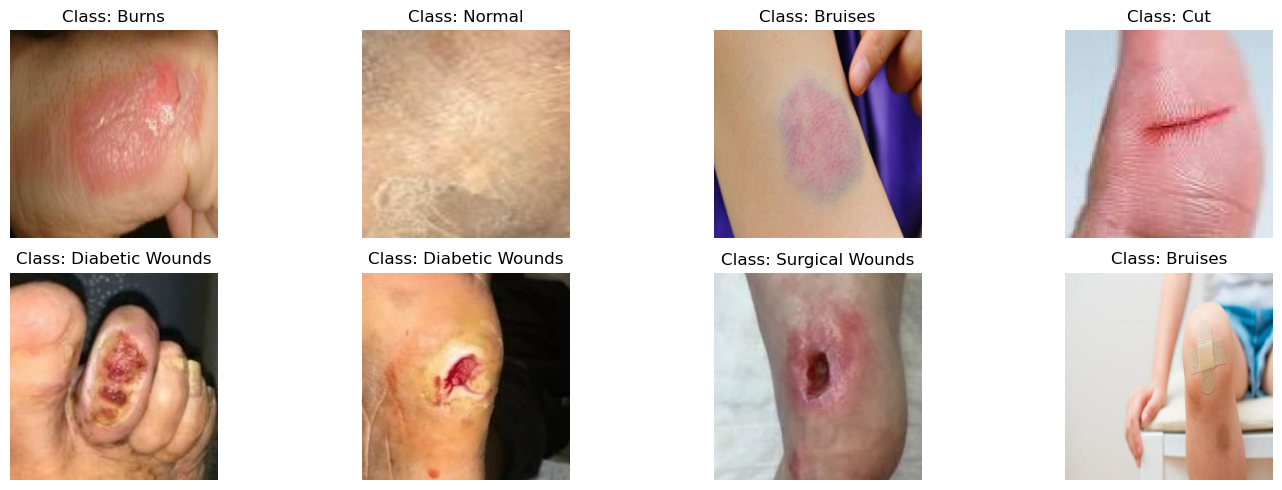


--- Sample images from Testing Set ---
Converting dataset to NumPy...
Concatenating all batches...


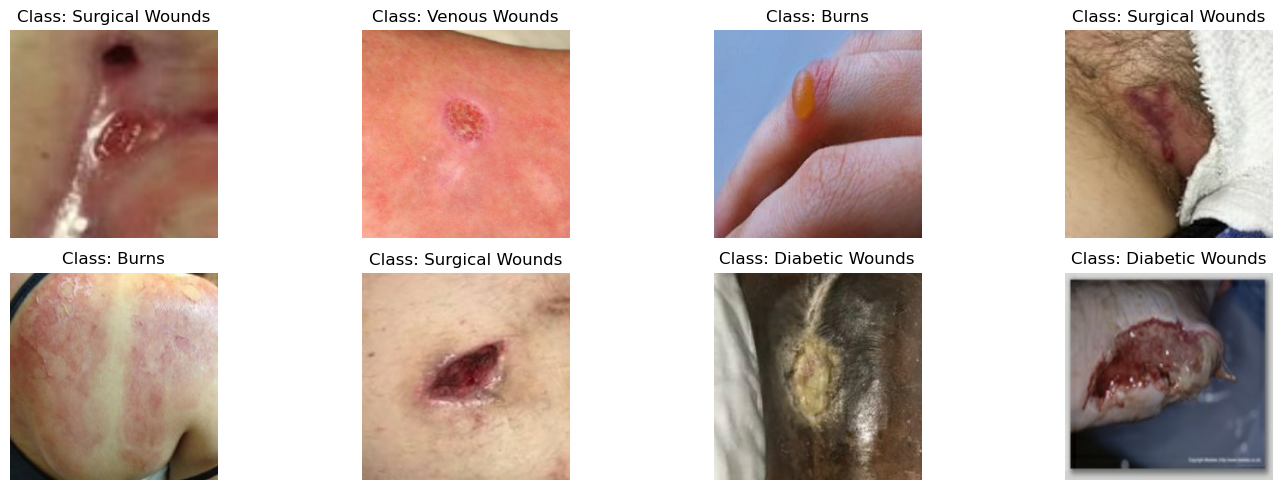

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling (Rescaling)         │ (None, 224, 224, 3)       │               0 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ normalization (Normalization) │ (None, 224, 224, 3)       │               7 │ rescaling[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ rescaling_1 (Rescaling)       │ (None, 224, 224, 3)       │               0 │ normalization[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv_pad (ZeroPadding2D) │ (None, 225, 225, 3)       │               0 │ rescaling_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_conv (Conv2D)            │ (None, 112, 112, 32)      │             864 │ stem_conv_pad[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_bn (BatchNormalization)  │ (None, 112, 112, 32)      │             128 │ stem_conv[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ stem_activation (Activation)  │ (None, 112, 112, 32)      │               0 │ stem_bn[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_dwconv                │ (None, 112, 112, 32)      │             288 │ stem_activation[0][0]      │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_bn                    │ (None, 112, 112, 32)      │             128 │ block1a_dwconv[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_activation            │ (None, 112, 112, 32)      │               0 │ block1a_bn[0][0]           │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_squeeze            │ (None, 32)                │               0 │ block1a_activation[0][0]   │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reshape (Reshape)  │ (None, 1, 1, 32)          │               0 │ block1a_se_squeeze[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_reduce (Conv2D)    │ (None, 1, 1, 8)           │             264 │ block1a_se_reshape[0][0]   │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block1a_se_expand (Conv2D)    │ (None, 1, 1, 32)          │             288 │ block1a_se_reduce[0][0]    │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 6,588,049 (25.13 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 6,575,239 (25.08 MB)

In [9]:
def display_images(images, labels, class_names_list, n=12, size=(15, 5)):
    n_display = min(n, len(images))
    indices = np.random.choice(len(images), n_display, replace=False)

    num_per_row = 4
    rows = (n_display + num_per_row - 1) // num_per_row
    fig, axes = plt.subplots(rows, num_per_row, figsize=size)
    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        img, label_info = images[idx], labels[idx]
        # Normalize for display if needed
        if np.max(img) <= 1.0 and np.min(img) >= 0.0:
            img_disp = (img * 255).astype("uint8")
        else:
            img_disp = ((img - np.min(img)) / (np.max(img) - np.min(img)) * 255).astype("uint8")

        axes[i].imshow(img_disp)
        # Integer or one-hot label
        class_index = int(np.argmax(label_info)) if hasattr(label_info, "__len__") and len(label_info) > 1 else int(label_info)
        axes[i].set_title(f'Class: {class_names_list[class_index]}')
        axes[i].axis('off')

    for j in range(len(indices), len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

print("\n--- Sample images from Training Set ---")
x_display, y_display = dataset_to_numpy(display_dataset)
display_images(x_display, y_display, class_names_list=class_names, n=8)

print("\n--- Sample images from Validation Set ---")
val_display_dataset = validation_data.map(lambda x, y: (preprocess_for_display(x), y))
x_val_display, y_val_display = dataset_to_numpy(val_display_dataset)
display_images(x_val_display, y_val_display, class_names_list=class_names, n=8)

print("\n--- Sample images from Testing Set ---")
test_display_dataset = testing_data.map(lambda x, y: (preprocess_for_display(x), y))
x_test_display, y_test_display = dataset_to_numpy(test_display_dataset)
display_images(x_test_display, y_test_display, class_names_list=class_names, n=8)

# -----------------------
# Model: EfficientNetB1 (frozen base) + GAP + Dropout + Dense(NUM_CLASSES)
# -----------------------
input_layer = layers.Input(shape=(224, 224, 3))
base_model = EfficientNetB1(weights='imagenet', include_top=False, input_tensor=input_layer)
base_model.trainable = False  # freeze base

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation='softmax', name="dense_1")(x)

model_efficientnet = models.Model(inputs=input_layer, outputs=output)
model_efficientnet.summary()


In [10]:
opt = optimizers.SGD(learning_rate=1e-4)

model_efficientnet.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Starting model training ---")
# Option A: train from NumPy arrays
history = model_efficientnet.fit(
    x=x_train, y=y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=10,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("--- Evaluating on test set ---")
test_loss, test_acc = model_efficientnet.evaluate(x_test, y_test_cat, batch_size=BATCH_SIZE, verbose=1)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

--- Starting model training ---
Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.0968 - loss: 2.5088 - val_accuracy: 0.0750 - val_loss: 2.4059
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.0998 - loss: 2.4917 - val_accuracy: 0.0781 - val_loss: 2.3809
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.1103 - loss: 2.4584 - val_accuracy: 0.0875 - val_loss: 2.3569
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.1191 - loss: 2.4148 - val_accuracy: 0.0906 - val_loss: 2.3339
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.1122 - loss: 2.4129 - val_accuracy: 0.0938 - val_loss: 2.3116
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.1236 - loss: 2.3813 - val_accuracy: 0.1125 - val_loss: 2.2902
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.1294 - loss: 2.3896 - val_accuracy: 0.1219 - val_loss: 2.2698
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.1328 - loss: 2.3462 - 

In [11]:
y_pred_probs = model_efficientnet.predict(x_val, verbose=0)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

y_true_input = y_val if 'y_val' in globals() else y_val_cat
if y_true_input.ndim == 1:
    y_true_classes = y_true_input.astype(int)
else:
    y_true_classes = np.argmax(y_true_input, axis=1).astype(int)


n_classes = y_pred_probs.shape[1]
assert y_pred_classes.shape[0] == y_true_classes.shape[0], "Jumlah sampel prediksi & ground-truth tidak sama."

# --- Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, classification_report, confusion_matrix
)

acc     = accuracy_score(y_true_classes, y_pred_classes)
prec    = precision_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
rec     = recall_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
f1      = f1_score(y_true_classes, y_pred_classes, average='weighted', zero_division=0)
bal_acc = balanced_accuracy_score(y_true_classes, y_pred_classes)

print(f"\nAccuracy          : {acc:.4f}")
print(f"Precision (wgt)   : {prec:.4f}")
print(f"Recall (wgt)      : {rec:.4f}")
print(f"F1 Score (wgt)    : {f1:.4f}")
print(f"Balanced Accuracy : {bal_acc:.4f}")


Accuracy          : 0.1531
Precision (wgt)   : 0.2189
Recall (wgt)      : 0.1531
F1 Score (wgt)    : 0.1506
Balanced Accuracy : 0.1165



Classification Report:
                 precision    recall  f1-score   support

      Abrasions       0.00      0.00      0.00        19
        Bruises       0.05      0.29      0.08        17
          Burns       0.00      0.00      0.00         9
            Cut       0.33      0.09      0.14        11
Diabetic Wounds       0.06      0.02      0.03        57
     Laseration       0.00      0.00      0.00        18
         Normal       0.00      0.00      0.00        15
Pressure Wounds       0.35      0.26      0.30        68
Surgical Wounds       0.16      0.36      0.22        42
  Venous Wounds       0.50      0.14      0.22        64

       accuracy                           0.15       320
      macro avg       0.14      0.12      0.10       320
   weighted avg       0.22      0.15      0.15       320



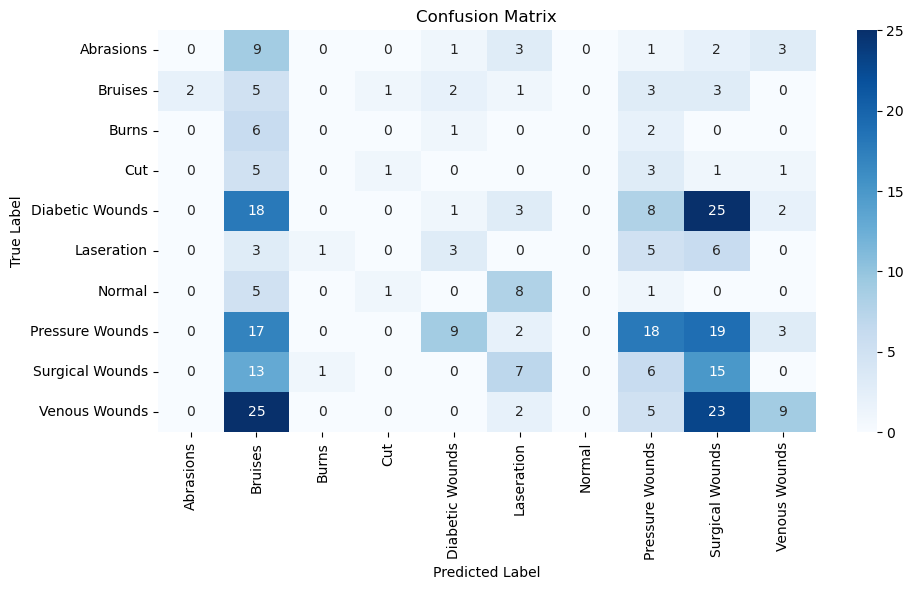

In [12]:
# --- Classification report ---
try:
    target_names = class_names if len(class_names) == n_classes else [f"class_{i}" for i in range(n_classes)]
except NameError:
    target_names = [f"class_{i}" for i in range(n_classes)]

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names, zero_division=0))

# --- Confusion Matrix ---
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes, labels=np.arange(n_classes))

plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


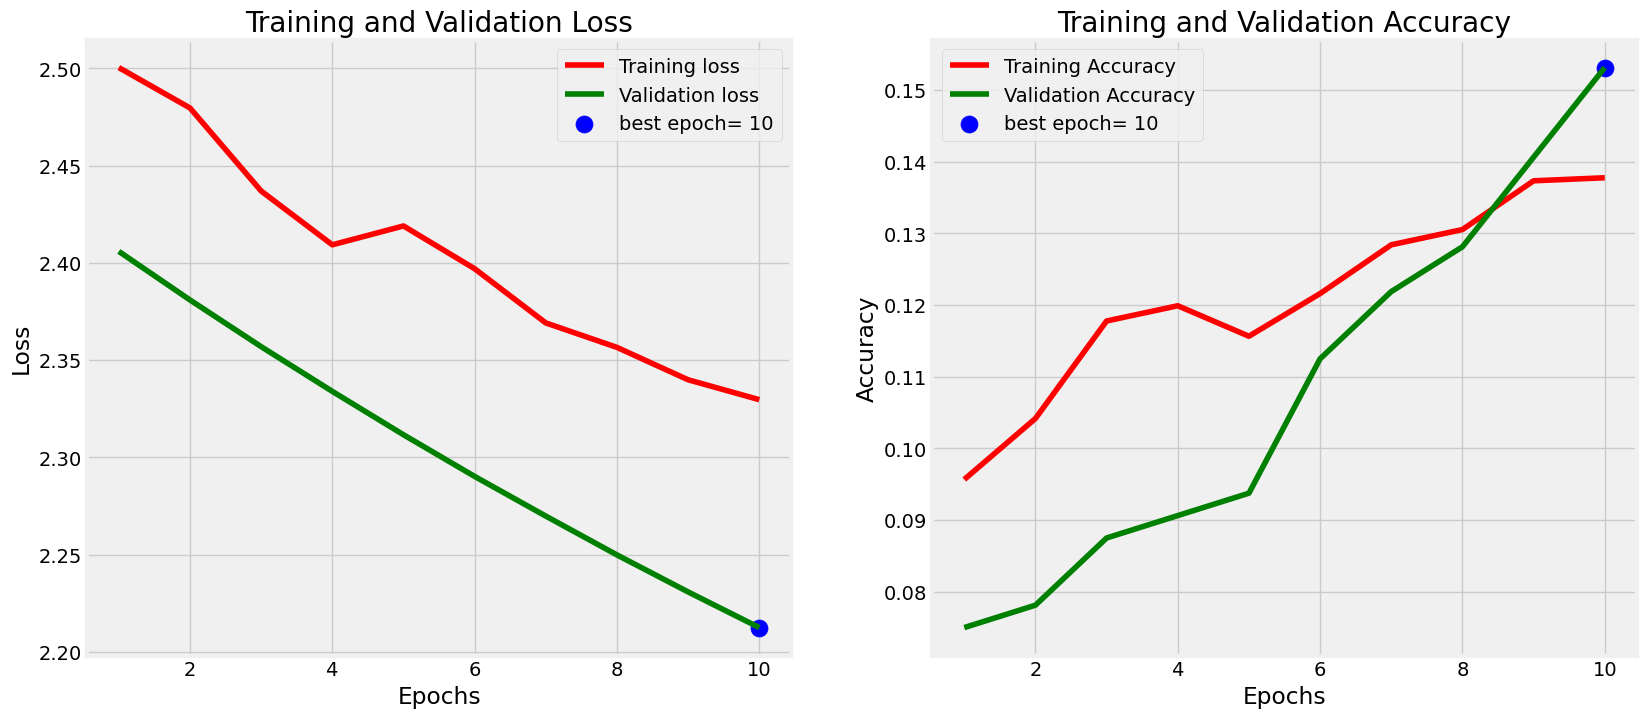

In [13]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'

plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model

def predict_single_image(image_path, model, class_names, target_size=(224, 224)):

    
    img = load_img(image_path, target_size=target_size)
    
    
    img_array = img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    
    
    img_preprocessed = preprocess_input(img_batch.astype(np.float32))
    

    predictions = model.predict(img_preprocessed)
    
    
    predicted_index = np.argmax(predictions, axis=1)[0]
    predicted_class = class_names[predicted_index]
    
    
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis("off")
    plt.show()
    
    
    print("Prediction probabilities:", predictions)
    print("Predicted class:", predicted_class)
    
    
    output_path = "predicted_image.jpg"
    plt.imsave(output_path, np.array(img))
    print(f"Gambar dengan hasil prediksi telah disimpan di: {output_path}")

# Load model from the .h5 file
model_efficientnet = load_model("model_efficientnetB1.h5")
print("Model loaded successfully from model_efficientnetB1.h5")


Class_names: [
    "Abrasions", "Bruises", "Burns", 
    "Cut", "Diabetic Wounds", "Laseration", 
    "Normal", "Pressure Wounds", "Surgical Wounds", 
    "Venous Wounds"
]

# Define the path to the image you want to predict
image_path = r"C:\Users\User\Downloads\Wound_dataset copy\Burns\burns (11).jpg"

# Make a prediction on the single image
predict_single_image(image_path, model_efficientnet, class_names)

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = 'model_efficientnetB1.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)